# Basics

To get acquainted with LangGraph's key concepts and features, complete the following LangGraph basics tutorials series:

- Build a basic chatbot
- Add tools
- Add memory


### 1. Build a BASIC CHATBOT

In this tutorial, you will build a basic chatbot. This chatbot is the basis for the following series of tutorials where you will progressively add more sophisticated capabilities, and be introduced to key LangGraph concepts along the way. 

#### Installation

In [40]:
# !pip install --upgrade langchain langchain-google-genai google-generativeai


In [41]:
!pip show langchain
#0.3.26

Name: langchain
Version: 0.3.26
Summary: Building applications with LLMs through composability
Home-page: 
Author: 
Author-email: 
License: MIT
Location: C:\Users\esvit\anaconda3\Lib\site-packages
Requires: langchain-core, langchain-text-splitters, langsmith, pydantic, PyYAML, requests, SQLAlchemy
Required-by: embedchain, langchain-community, langchain-tavily


In [42]:
!pip show  langchain-google-genai 
#2.0.10

Name: langchain-google-genai
Version: 2.1.8
Summary: An integration package connecting Google's genai package and LangChain
Home-page: https://github.com/langchain-ai/langchain-google
Author: 
Author-email: 
License: MIT
Location: C:\Users\esvit\anaconda3\Lib\site-packages
Requires: filetype, google-ai-generativelanguage, langchain-core, pydantic
Required-by: 


In [43]:
!pip show google-generativeai
#0.8.5

#### Create a State Graph

A **StateGraph** object defines the structure of our chatbot as a "state machine". 
We'll add **nodes** to represent the llm and functions our chatbot can call and 
**edges** to specify how the bot should transition between these functions.

In [44]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

- Each node can receive the current State as input and output an update to the state.
- Updates to messages will be appended to the existing list rather than overwriting it, thanks to the prebuilt add_messages function used with the Annotated syntax.


#### Add a Node

- Nodes represent units of work and are typically regular Python functions.

In [45]:
import os
from langchain.chat_models import init_chat_model

os.environ["GOOGLE_API_KEY"] = "YOUR_GOOGLE_API_KEY"

llm = init_chat_model(model="google_genai:gemini-2.0-flash")

In [46]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


# The first argument is the unique node name
# The second argument is the function or object that will be called whenever
# the node is used.
graph_builder.add_node("chatbot", chatbot)

**Notice**- how the chatbot node function takes the current State as input and returns a dictionary containing an updated messages list under the key "messages". This is the basic pattern for all LangGraph node functions.

The add_messages function in our State will append the LLM's response messages to whatever messages are already in the state

#### Add an entry Point

In [47]:
graph_builder.add_edge(START, "chatbot")

#### Add an exit point

In [48]:
graph_builder.add_edge("chatbot", END)

#### COMPILE THE GRAPH

In [49]:
graph = graph_builder.compile()

#### Viz

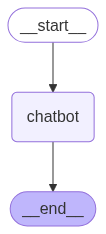

In [50]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

#### Run a chatbot

In [51]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

while True:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        stream_graph_updates(user_input)


   

User:  Hello


Assistant: Hello! How can I help you today?


User:  my freind name is Jane


Assistant: Okay, thanks for letting me know your friend's name is Jane! Is there anything you'd like to tell me about Jane or anything I can help you with regarding her?


User:  exit


Goodbye!


# 2 - Add tools

In [52]:
# !pip install -U langchain-tavily

In [53]:
os.environ["TAVILY_API_KEY"]="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"

In [54]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tools = [tool]
tool.invoke("at what points sensex closed?")

{'query': 'at what points sensex closed?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.moneycontrol.com/news/business/markets/stock-market-live-sensex-nifty-50-share-price-gift-nifty-latest-updates-21-07-2025-liveblog-13300395.html',
   'title': 'Closing Bell: Nifty near 25100, Sensex up 443 pts - Moneycontrol',
   'content': 'At close, the Sensex was up 442.61 points or 0.54 percent at 82,200.34, and the Nifty was up 122.30 points or 0.49 percent at 25,090.70.',
   'score': 0.8449346,
   'raw_content': None},
  {'url': 'https://www.deccanherald.com/business/markets/sensex-declines-14868-points-nifty-drops-6755-points-in-early-trade-3639801',
   'title': 'Sensex declines 148.68 points; Nifty drops 67.55 points in early trade',
   'content': 'Sensex declines 148.68 points; Nifty drops 67.55 points in early trade. Benchmark Sensex tanked 501 points while Nifty closed below the',
   'score': 0.7092009,
   'raw_content': None}],
 'respons

#### Define the graph

For the StateGraph you created in the first tutorial, add bind_tools on the LLM. This lets the LLM know the correct JSON format to use if it wants to use the search engine.

In [109]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.messages import BaseMessage
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition


In [110]:

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [111]:

tool = TavilySearch(max_results=2)
tools = [tool]
llm_with_tools = llm.bind_tools(tools)

In [112]:



def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

In [113]:

tool_node = ToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)

In [114]:



graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
# Any time a tool is called, we return to the chatbot to decide the next step
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
graph = graph_builder.compile()

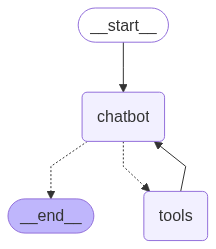

In [115]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

The chatbot can now use tools to answer user questions, but it does not remember the context of previous interactions. This limits its ability to have coherent, multi-turn conversations.

- LangGraph solves this problem through **persistent checkpointing**. 
- If you provide a checkpointer when compiling the graph and a thread_id when calling your graph, LangGraph automatically saves the state after each step. When you invoke the graph again using the same thread_id, the graph loads its saved state, allowing the chatbot to pick up where it left off.

#### . Create a MemorySaver checkpointer

In [29]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

**Note** Mmeory saver is in - memory for production we can use SqliteSaver or PostgresSaver

In [30]:
graph = graph_builder.compile(checkpointer=memory)

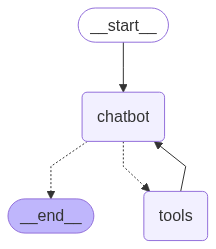

In [31]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [32]:
config = {"configurable": {"thread_id": "1"}}

In [33]:
user_input = "Hi there! My name is Will."

# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there! My name is Will.
================================== Ai Message ==================================

Hi Will! How can I help you today?


In [34]:
user_input = "Remember my name?"

# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Remember my name?
================================== Ai Message ==================================

Yes, your name is Will.


In [35]:
snapshot = graph.get_state(config)
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='Hi there! My name is Will.', additional_kwargs={}, response_metadata={}, id='ed5c1725-5154-4fb8-a8f6-419542d7d2f5'), AIMessage(content='Hi Will! How can I help you today?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--79c4e074-7c0a-4b54-9ed1-d2c337081179-0', usage_metadata={'input_tokens': 1099, 'output_tokens': 11, 'total_tokens': 1110, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='Remember my name?', additional_kwargs={}, response_metadata={}, id='1ead3fc0-48ae-4976-ac0a-f9cbcf43aebf'), AIMessage(content='Yes, your name is Will.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--da07cfd8-9b03-4d85-b25f-ffc5dbcca83d-0', 

# Workflows and Agents

- A workflow is just a defined path of actions, where each step leads to the next, like a flowchart or a recipe

#### Intialise LLM

In [116]:
# !pip install -U langchain-google-genai

In [117]:
import os
from langchain.chat_models import init_chat_model

os.environ["GOOGLE_API_KEY"] = "YOUR_GOOGLE_API_KEY"

llm = init_chat_model(model="google_genai:gemini-2.0-flash")

### Building Blocks: The Augmented LLM

In [118]:
# Schema for structured output
from pydantic import BaseModel, Field

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Query that is optimized web search.")
    justification: str = Field(
        None, description="Why this query is relevant to the user's request."
    )


# Augment the LLM with schema for structured output
structured_llm = llm.with_structured_output(SearchQuery)

# Invoke the augmented LLM
output = structured_llm.invoke("How does Calcium CT score relate to high cholesterol?")



In [119]:
output

SearchQuery(search_query='Calcium CT score and high cholesterol', justification='To find the relationship between Calcium CT score and high cholesterol.')

In [5]:
# Define a tool
def multiply(a: int, b: int) -> int:
    return a * b

# Augment the LLM with tools
llm_with_tools = llm.bind_tools([multiply])

# Invoke the LLM with input that triggers the tool call
msg = llm_with_tools.invoke("What is 2 times 3?")

# Get the tool call
msg.tool_calls

[{'name': 'multiply',
  'args': {'b': 3.0, 'a': 2.0},
  'id': '94ab3bdf-0423-4402-b86d-13becab82817',
  'type': 'tool_call'}]

### Prompt chaining

Prompt chaining decomposes a task into a sequence of steps, where each LLM call processes the output of the previous one. You can add programmatic checks (see "gate” in the diagram below) on any intermediate steps to ensure that the process is still on track.

When to use this workflow: This workflow is ideal for situations where the task can be easily and cleanly decomposed into fixed subtasks. The main goal is to trade off latency for higher accuracy, by making each LLM call an easier task.

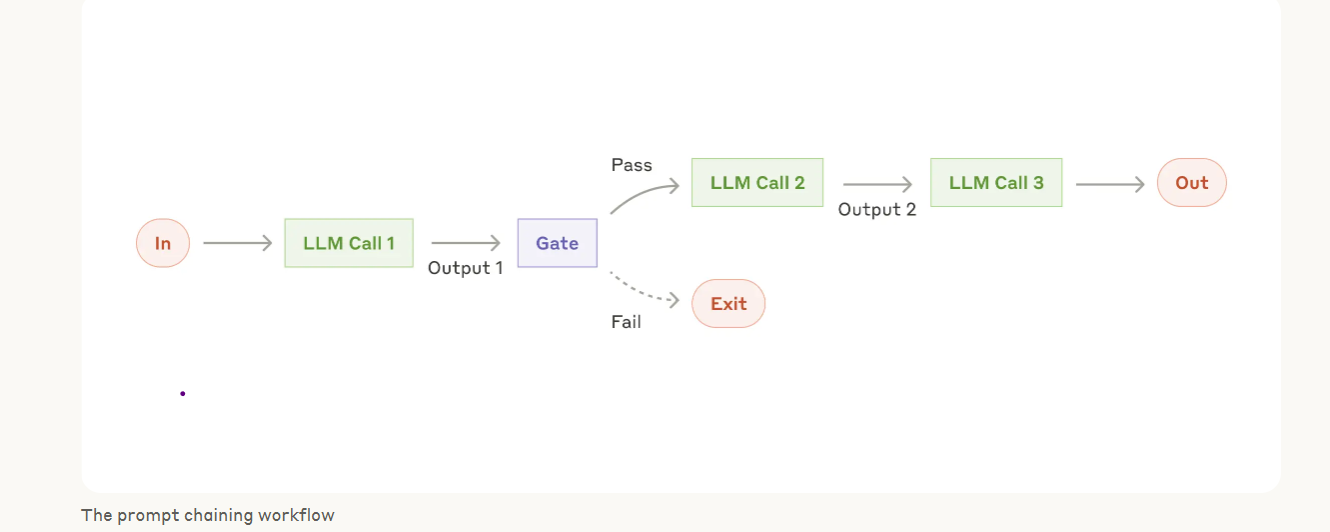

In [11]:
# !pip install langgraph

In [135]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


# Graph state
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str

In [154]:



# Nodes
def generate_joke(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content}


def check_punchline(state: State):
    """Gate function to check if the joke has a punchline"""
    
    # Simple check - does the joke contain "?" or "!"
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"


def improve_joke(state: State):
    """Second LLM call to improve the joke"""

    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content}


def polish_joke(state: State):
    """Third LLM call for final polish"""

    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}





In [150]:
# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)


In [155]:
# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END}
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


ValueError: Branch with name `check_punchline` already exists for node `generate_joke`

In [156]:


# Invoke
state = chain.invoke({"topic": "what is science "})
print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")
if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("Joke failed quality gate - no punchline detected!")

Initial joke:
Why did the atom cross the road?

Because it heard there was free association, and science said it was a possibility!

--- --- ---

Improved joke:
Okay, I like the direction you're going! Here are a few options that build on your idea and add more wordplay, playing with the "atom" and "association" aspects:

**Option 1 (Focus on Bonding):**

> Why did the atom cross the road?
>
> Because it heard there was free association, and it was hoping to bond with a new nucleus! It was tired of its current relationship, said it was feeling a bit too *ionic*.

**Option 2 (Focus on Charge):**

> Why did the atom cross the road?
>
> Because it heard there was free association, and it was hoping to find a positive experience! It was tired of being negatively charged all the time and wanted to find some equilibrium.

**Option 3 (Slightly More Absurd):**

> Why did the atom cross the road?
>
> Because it heard there was free association! It wanted to see if it could finally associate wit

In [157]:


# Invoke
state = chain.invoke({"topic": "Science"})
print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")
if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("Joke failed quality gate - no punchline detected!")

Initial joke:
Why did the atom cross the road? 

Because it heard there was fission!

--- --- ---

Improved joke:
Okay, here are a few ways to punch up the "Why did the atom cross the road? Because it heard there was fission!" joke with some wordplay:

**Option 1 (Focusing on the "road"):**

> Why did the atom cross the road?
>
> Because it heard there was fission happening on the other side, and it wanted to get its **atomic number** on the action!  It was really **element-al** to its plans.

**Option 2 (Playing on "fission" and "fishing"):**

> Why did the atom cross the road?
>
> Because it heard there was fission going on! It was hoping to **catch a few neutrons**... maybe even a new isotope!

**Option 3 (More absurd and pun-heavy):**

> Why did the atom cross the road?
>
> Because it heard there was fission!  It was hoping to **bond** with some new elements, maybe even find a **stable relationship**. Plus, it had a **mole-tiviation** to see what all the excitement was about!

**Op

### Parallelization

LLMs can sometimes work simultaneously on a task and have their outputs aggregated programmatically. This workflow, parallelization, manifests in two key variations:
- Sectioning: Breaking a task into independent subtasks run in parallel.
- Voting: Running the same task multiple times to get diverse outputs.

When to use this workflow: Parallelization is effective when the divided subtasks can be parallelized for speed, or when multiple perspectives or attempts are needed for higher confidence results. For complex tasks with multiple considerations, LLMs generally perform better when each consideration is handled by a separate LLM call, allowing focused attention on each specific aspect.

In [158]:
# Graph state
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str



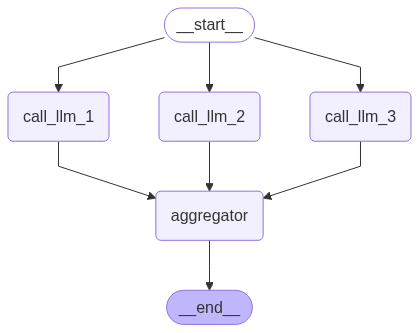

In [159]:

# Nodes
def call_llm_1(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def call_llm_2(state: State):
    """Second LLM call to generate story"""

    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story": msg.content}


def call_llm_3(state: State):
    """Third LLM call to generate poem"""

    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem": msg.content}


def aggregator(state: State):
    """Combine the joke and story into a single output"""

    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}


# Build workflow
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# Add edges to connect nodes
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)
parallel_workflow = parallel_builder.compile()

# Show workflow
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))



In [160]:
# Invoke
state = parallel_workflow.invoke({"topic": "cats"})
print(state["combined_output"])

Here's a story, joke, and poem about cats!

STORY:
The alley behind Mrs. Higgins' bakery was a kingdom ruled by cats. Not in the violent, territorial way of stray dogs, but in a subtle, feline fashion. It was a place of shared sunbeams, negotiated scraps, and unspoken alliances. At the heart of this kingdom was Clementine, a ginger tabby with emerald eyes that seemed to hold the wisdom of a hundred generations of alley cats.

Clementine wasn't the biggest, or the fiercest. But she had a way of understanding the rhythms of the alley, the ebb and flow of human activity, the subtle shifts in the wind that carried the scent of freshly baked bread. She knew which bins held the best discarded pastries, which delivery men were kind, and which dogs were best avoided.

One day, a newcomer arrived. A sleek, black cat with amber eyes, he was all angles and muscle, a stark contrast to the relaxed, slightly plump residents of the alley. He called himself Midnight, and he immediately tried to assert

### Routing

Routing classifies an input and directs it to a specialized followup task. This workflow allows for separation of concerns, and building more specialized prompts. Without this workflow, optimizing for one kind of input can hurt performance on other inputs.

When to use this workflow: Routing works well for complex tasks where there are distinct categories that are better handled separately, and where classification can be handled accurately, either by an LLM or a more traditional classification model/algorithm.

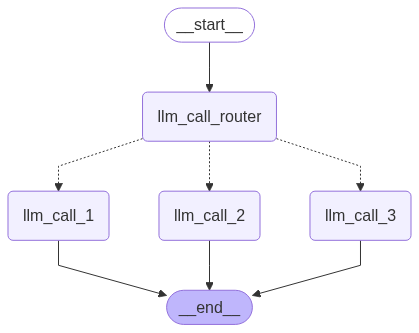

<function IPython.core.display_functions.display(*objs, include=None, exclude=None, metadata=None, transient=None, display_id=None, raw=False, clear=False, **kwargs)>

In [27]:
from typing_extensions import Literal
from langchain_core.messages import HumanMessage, SystemMessage


# Schema for structured output to use as routing logic
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="The next step in the routing process"
    )


# Augment the LLM with schema for structured output
router = llm.with_structured_output(Route)


# State
class State(TypedDict):
    input: str
    decision: str
    output: str


# Nodes
def llm_call_1(state: State):
    """Write a story"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_2(state: State):
    """Write a joke"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_3(state: State):
    """Write a poem"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_router(state: State):
    """Route the input to the appropriate node"""

    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke, or poem based on the user's request."
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return {"decision": decision.step}


# Conditional edge function to route to the appropriate node
def route_decision(state: State):
    # Return the node name you want to visit next
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"


# Build workflow
router_builder = StateGraph(State)

# Add nodes
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

# Add edges to connect nodes
router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {  # Name returned by route_decision : Name of next node to visit
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
)
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

# Compile workflow
router_workflow = router_builder.compile()

# Show the workflow
display(Image(router_workflow.get_graph().draw_mermaid_png()))

display

In [28]:
# Invoke
state = router_workflow.invoke({"input": "Write me a joke about cats"})
print(state["output"])

Why did the cat join the Red Cross?

Because he wanted to be a first-aid kit!


### Evaluator-optimizer

In the evaluator-optimizer workflow, one LLM call generates a response while another provides evaluation and feedback in a loop.

When to use this workflow: This workflow is particularly effective when we have clear evaluation criteria, and when iterative refinement provides measurable value. The two signs of good fit are, first, that LLM responses can be demonstrably improved when a human articulates their feedback; and second, that the LLM can provide such feedback. This is analogous to the iterative writing process a human writer might go through when producing a polished document.

In [165]:
# Graph state
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str


# Schema for structured output to use in evaluation
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if the joke is funny or not.",
    )
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it.",
    )

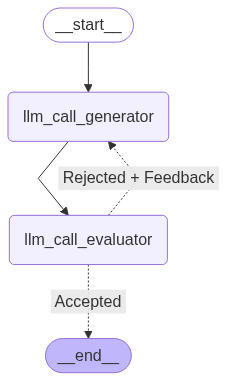

<function IPython.core.display_functions.display(*objs, include=None, exclude=None, metadata=None, transient=None, display_id=None, raw=False, clear=False, **kwargs)>

In [172]:



# Augment the LLM with schema for structured output
evaluator = llm.with_structured_output(Feedback)


# Nodes
def llm_call_generator(state: State):
    """LLM generates a joke"""

    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def llm_call_evaluator(state: State):
    """LLM evaluates the joke"""

    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}


# Conditional edge function to route back to joke generator or end based upon feedback from the evaluator
def route_joke(state: State):
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"


# Build workflow
optimizer_builder = StateGraph(State)

# Add the nodes
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

# Add edges to connect nodes
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {  # Name returned by route_joke : Name of next node to visit
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

# Compile the workflow
optimizer_workflow = optimizer_builder.compile()

# Show the workflow
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))
display

In [173]:

# Invoke
state = optimizer_workflow.invoke({"topic": "Cats"})
print(state["joke"])

Why did the cat join the Red Cross?

Because it had first aid kit!
